# Week 5: AI-Assisted Triage – Data Exploration (Interim)


In [19]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path


DATA_PATH = Path("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")

df = pd.read_csv(DATA_PATH, index_col=0)

print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(55121, 225)


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
structured = [c for c in df.columns if not c.startswith("cc_")]
cc_flags = [c for c in df.columns if c.startswith("cc_")]

dep_name         0.0
esi              0.0
age              0.0
gender           0.0
ethnicity        0.0
race             0.0
lang             0.0
religion         0.0
maritalstatus    0.0
employstatus     0.0
dtype: float64


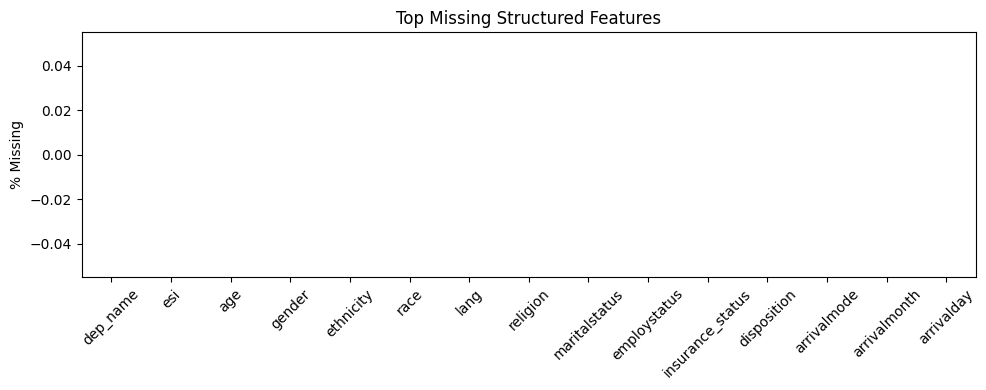

In [21]:
missing_percent = df[structured].isna().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

print(missing_percent.head(10))

top_missing = missing_percent.head(15)   # <-- REMOVE FILTER

plt.figure(figsize=(10,4))
top_missing.plot(kind="bar")
plt.title("Top Missing Structured Features")
plt.ylabel("% Missing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

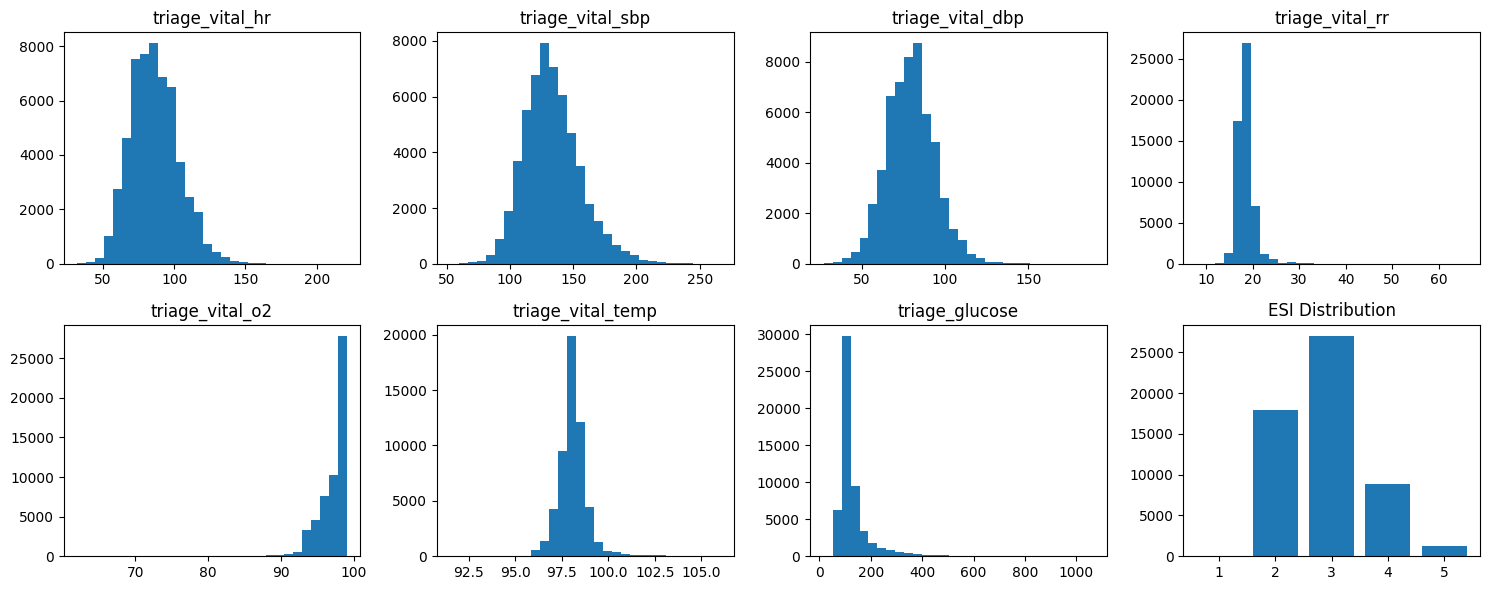

In [22]:
vitals = [
    "triage_vital_hr","triage_vital_sbp","triage_vital_dbp",
    "triage_vital_rr","triage_vital_o2","triage_vital_temp",
    "triage_glucose"
]

fig, axes = plt.subplots(2, 4, figsize=(15,6))
axes = axes.ravel()

for i, col in enumerate(vitals):
    vals = pd.to_numeric(df[col], errors="coerce").dropna()
    axes[i].hist(vals, bins=30)
    axes[i].set_title(col)

esi_counts = df["esi"].value_counts().sort_index()
axes[-1].bar(esi_counts.index, esi_counts.values)
axes[-1].set_title("ESI Distribution")

plt.tight_layout()
plt.show()

In [23]:
def outlier_report(df, col):
    x = pd.to_numeric(df[col], errors="coerce").dropna()

    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1

    return ((x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)).sum()

for col in vitals:
    print(col, outlier_report(df, col))

triage_vital_hr 578
triage_vital_sbp 1028
triage_vital_dbp 726
triage_vital_rr 2366
triage_vital_o2 1505
triage_vital_temp 3554
triage_glucose 5673


In [24]:
vitals_numeric = df[vitals].apply(pd.to_numeric, errors="coerce")

vital_corr = vitals_numeric.corrwith(df["esi"]).sort_values()
print(vital_corr)

triage_vital_rr     -0.095325
triage_vital_hr     -0.095191
triage_glucose      -0.077824
triage_vital_temp   -0.021820
triage_vital_sbp     0.001304
triage_vital_dbp     0.046468
triage_vital_o2      0.177859
dtype: float64


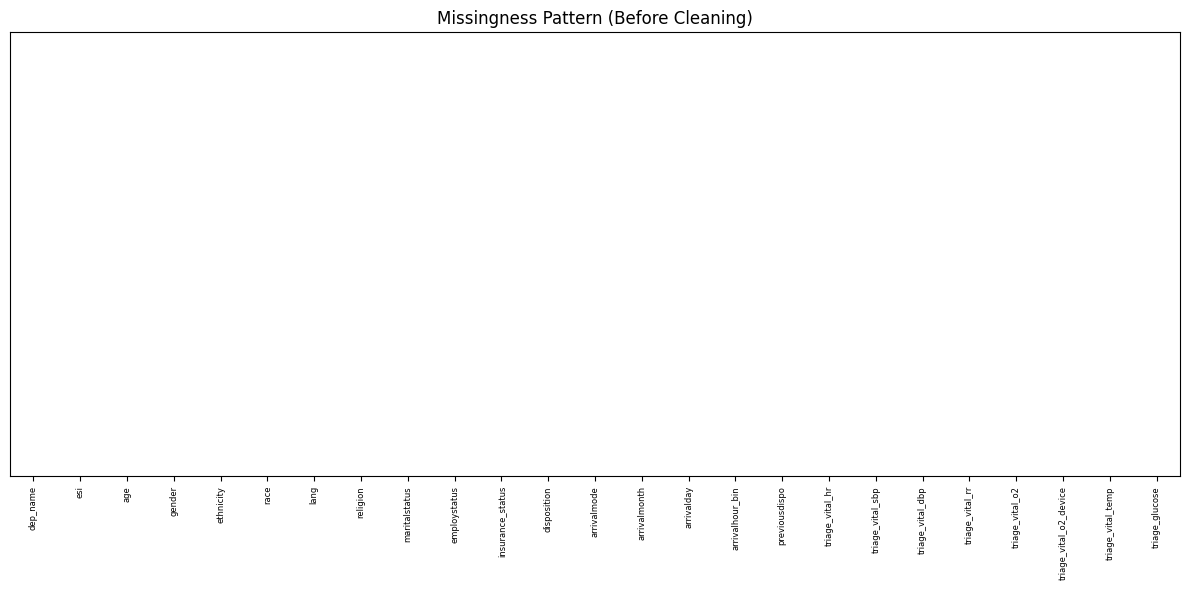

In [25]:
structured = [c for c in df.columns if not c.startswith("cc_")]
missing = df[structured].isna().values

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(missing, aspect="auto", cmap="gray_r", interpolation="none")

ax.set_title("Missingness Pattern (Before Cleaning)")

ax.set_xticks(np.arange(len(structured)))
ax.set_xticklabels(structured, rotation=90, fontsize=6)

ax.set_yticks([])

plt.tight_layout()
plt.show()